# Patterns and Potential Research Questions

## Objective

Explore time trends, geographic differences and building categories
to identify potential research questions. Assess whether the two
datasets can support comparisons at a common geographic and temporal level.

## Exploration Scope

- Building Activity: 2023-Q1 to 2025-Q4.
- Building Approvals: January 2023 to December 2025.
- Geographic and measure coverage will be checked from the extracted data.

In [5]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.6/9.3 MB 12.3 MB/s eta 0:00:01
   -------------------- ------------------- 4.7/9.3 MB 11.2 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 10.5 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.3 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 9.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------ --------------------- 3.4/7.2 MB 17.7 MB/s eta 0:00:01
   ------------------------------------- -- 6.8/7.2 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 15.4 MB/s  0:00:00

   -----------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = Path("../data/raw")

activity_file = sorted(
    RAW_DIR.glob("building_activity_*.csv")
)[-1]

approvals_file = sorted(
    RAW_DIR.glob("ba_sa2_*.csv")
)[-1]

activity = pd.read_csv(activity_file)
approvals = pd.read_csv(approvals_file)

print("Activity file:", activity_file.name)
print("Activity shape:", activity.shape)

print("\nApprovals file:", approvals_file.name)
print("Approvals shape:", approvals.shape)

Activity file: building_activity_20261005T014245069192Z.csv
Activity shape: (2208, 15)

Approvals file: ba_sa2_20261005T014247709894Z.csv
Approvals shape: (1782, 14)


In [7]:
print("BUILDING_ACTIVITY columns:")
print(activity.columns.tolist())
display(activity.head())

print("BA_SA2 columns:")
print(approvals.columns.tolist())
display(approvals.head())

BUILDING_ACTIVITY columns:
['DATAFLOW', 'MEASURE', 'REGION', 'PRICE_ADJ', 'BLD_WORK_TYPE', 'SECTOR_OWN', 'TYPE_BLDG', 'TSEST', 'FREQ', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE', 'UNIT_MULT', 'OBS_STATUS', 'OBS_COMMENT']


,DATAFLOW,MEASURE,REGION,PRICE_ADJ,BLD_WORK_TYPE,SECTOR_OWN,TYPE_BLDG,TSEST,FREQ,TIME_PERIOD,OBS_VALUE,UNIT_MEASURE,UNIT_MULT,OBS_STATUS,OBS_COMMENT
0,ABS:BUILDING_ACTIVITY(1.0.0),M1,2,CVM,TOT,9,TOT,20,Q,2023-Q1,12792219.0,AUD,3,NaN,NaN
1,ABS:BUILDING_ACTIVITY(1.0.0),M1,2,CVM,TOT,9,TOT,20,Q,2023-Q2,12673855.0,AUD,3,NaN,NaN
2,ABS:BUILDING_ACTIVITY(1.0.0),M1,2,CVM,TOT,9,TOT,20,Q,2023-Q3,12508261.0,AUD,3,NaN,NaN
3,ABS:BUILDING_ACTIVITY(1.0.0),M1,2,CVM,TOT,9,TOT,20,Q,2023-Q4,12660591.0,AUD,3,NaN,NaN
4,ABS:BUILDING_ACTIVITY(1.0.0),M1,2,CVM,TOT,9,TOT,20,Q,2024-Q1,12961226.0,AUD,3,NaN,NaN


BA_SA2 columns:
['DATAFLOW', 'MEASURE', 'SECTOR', 'WORK_TYPE', 'BUILDING_TYPE', 'REGION_TYPE', 'REGION', 'FREQ', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE', 'UNIT_MULT', 'OBS_STATUS', 'OBS_COMMENT']


,DATAFLOW,MEASURE,SECTOR,WORK_TYPE,BUILDING_TYPE,REGION_TYPE,REGION,FREQ,TIME_PERIOD,OBS_VALUE,UNIT_MEASURE,UNIT_MULT,OBS_STATUS,OBS_COMMENT
0,ABS:BA_SA2(2.0.0),1,1,TOT,TOT,STE,2,M,2023-01,2862.0,NUM,0,NaN,NaN
1,ABS:BA_SA2(2.0.0),1,1,TOT,TOT,STE,2,M,2023-02,4193.0,NUM,0,NaN,NaN
2,ABS:BA_SA2(2.0.0),1,1,TOT,TOT,STE,2,M,2023-03,4451.0,NUM,0,NaN,NaN
3,ABS:BA_SA2(2.0.0),1,1,TOT,TOT,STE,2,M,2023-04,3101.0,NUM,0,NaN,NaN
4,ABS:BA_SA2(2.0.0),1,1,TOT,TOT,STE,2,M,2023-05,4403.0,NUM,0,NaN,NaN


In [9]:
# Check available dimensions and units
checks = [
    ("BUILDING_ACTIVITY", activity, [
        "MEASURE", "REGION", "PRICE_ADJ", "BLD_WORK_TYPE",
        "SECTOR_OWN", "TYPE_BLDG", "TSEST",
        "UNIT_MEASURE", "UNIT_MULT"
    ]),
    ("BA_SA2", approvals, [
        "MEASURE", "SECTOR", "WORK_TYPE",
        "BUILDING_TYPE", "REGION_TYPE", "REGION",
        "UNIT_MEASURE", "UNIT_MULT"
    ])
]

for name, df, columns in checks:
    print(f"\n{name}")

    for column in columns:
        print(f"{column}: {df[column].dropna().unique().tolist()}")

    print("First period:", df["TIME_PERIOD"].min())
    print("Last period:", df["TIME_PERIOD"].max())
    print("Number of periods:", df["TIME_PERIOD"].nunique())


BUILDING_ACTIVITY
MEASURE: ['M1', 'M8', 'M3', 'M7', 'M6', 'M2', 'M5', 'M4']
REGION: ['2', 'AUS', '1', '7', '3', '6', '8', '4', '5']
PRICE_ADJ: ['CVM', 'CUR']
BLD_WORK_TYPE: ['TOT']
SECTOR_OWN: [9]
TYPE_BLDG: ['TOT']
TSEST: [20, 10, 30]
UNIT_MEASURE: ['AUD', 'NUM']
UNIT_MULT: [3, 0]
First period: 2023-Q1
Last period: 2025-Q4
Number of periods: 12

BA_SA2
MEASURE: [1, 2]
SECTOR: [1, 9, 5]
WORK_TYPE: ['TOT']
BUILDING_TYPE: ['TOT']
REGION_TYPE: ['STE', 'AUS']
REGION: ['2', '5', 'AUS', '6', '3', '8', '1', '7', '4']
UNIT_MEASURE: ['NUM', 'AUD']
UNIT_MULT: [0, 3]
First period: 2023-01
Last period: 2025-09
Number of periods: 33


In [18]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

url = (
    "https://data.api.abs.gov.au/rest/dataflow/"
    "ABS/BUILDING_ACTIVITY/1.0.0?references=all"
)

response = requests.get(url, timeout=120)
response.raise_for_status()

root = ET.fromstring(response.content)

ns = {
    "s": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure",
    "c": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/common"
}

labels = {}

for dimension in root.findall(".//s:Dimension", ns):
    dimension_id = dimension.get("id")

    if dimension_id not in ["MEASURE", "TSEST", "REGION"]:
        continue

    ref = dimension.find(
        "./s:LocalRepresentation/s:Enumeration/Ref", ns
    )

    if ref is None:
        continue

    for codelist in root.findall(".//s:Codelist", ns):
        if codelist.get("id") != ref.get("id"):
            continue

        labels[dimension_id] = {}

        for code in codelist.findall("./s:Code", ns):
            names = code.findall("./c:Name", ns)

            # Prefer an English label
            name = next(
                (
                    n for n in names
                    if n.get(
                        "{http://www.w3.org/XML/1998/namespace}lang"
                    ) == "en"
                ),
                names[0] if names else None
            )

            labels[dimension_id][code.get("id")] = (
                name.text if name is not None else ""
            )

for dimension_id in ["MEASURE", "TSEST"]:
    print(f"\n{dimension_id}")
    display(
        pd.Series(labels[dimension_id], name="Label")
        .rename_axis("Code")
        .to_frame()
    )


MEASURE


,Label
Code,
M1,Value of work done during quarter
M2,Value of work yet to be done
M3,Value of work commenced
M4,Value of work completed
M5,Value of work under construction
M6,Dwelling units commenced
M7,Dwelling units completed
M8,Dwelling units under construction



TSEST


,Label
Code,
10,Original
20,Seasonally Adjusted
30,Trend
40,Sensitivity Upper
50,Sensitivity Lower


In [19]:
def find_code(dimension, *keywords):
    matches = {
        code: label
        for code, label in labels[dimension].items()
        if all(
            word.lower() in label.lower()
            for word in keywords
        )
    }

    if len(matches) != 1:
        raise ValueError(
            f"Cannot select one code for {keywords}. "
            f"Matching labels: {matches}. "
            "Check the metadata table above."
        )

    return next(iter(matches))


commenced_code = find_code("MEASURE", "dwelling", "commenced")
completed_code = find_code("MEASURE", "dwelling", "completed")
construction_code = find_code(
    "MEASURE", "dwelling", "under construction"
)

series_code = find_code("TSEST", "original")

print("Commencements:", commenced_code)
print("Completions:", completed_code)
print("Under construction:", construction_code)
print("Series:", series_code)

Commencements: M6
Completions: M7
Under construction: M8
Series: 10


In [10]:
import requests
import xml.etree.ElementTree as ET

url = (
    "https://data.api.abs.gov.au/rest/dataflow/"
    "ABS/BA_SA2/2.0.0?references=all"
)

response = requests.get(url, timeout=120)
response.raise_for_status()

root = ET.fromstring(response.content)

ns = {
    "s": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/structure",
    "c": "http://www.sdmx.org/resources/sdmxml/schemas/v2_1/common"
}

# Find the codelist used by each selected dimension
for dimension in root.findall(".//s:Dimension", ns):
    dimension_id = dimension.get("id")

    if dimension_id not in ["MEASURE", "SECTOR"]:
        continue

    ref = dimension.find(
        "./s:LocalRepresentation/s:Enumeration/Ref", ns
    )

    if ref is None:
        continue

    codelist_id = ref.get("id")
    print(f"\n{dimension_id} — {codelist_id}")

    for codelist in root.findall(".//s:Codelist", ns):
        if codelist.get("id") == codelist_id:
            for code in codelist.findall("./s:Code", ns):
                name = code.find("./c:Name", ns)
                label = name.text if name is not None else ""
                print(f"{code.get('id')}: {label}")


MEASURE — CL_BA_MEASURE
1: Number of dwelling units
2: Value of building jobs
3: Number of building jobs valued $50,000 or more

SECTOR — CL_BA_OWNERSHIP
9: Total Sectors
1: Private Sector
5: Public Sector


In [20]:
building = activity[
    activity["MEASURE"].astype(str).isin([
        commenced_code,
        completed_code,
        construction_code
    ])
    & (activity["TSEST"].astype(str) == series_code)
    & (activity["BLD_WORK_TYPE"] == "TOT")
    & (activity["TYPE_BLDG"] == "TOT")
    & (activity["SECTOR_OWN"].astype(str) == "9")
    & (activity["UNIT_MEASURE"] == "NUM")
    & activity["REGION"].astype(str).isin(
        [str(code) for code in range(1, 9)]
    )
].copy()

assert not building.empty, "Bộ lọc không trả về dữ liệu."

building["REGION"] = building["REGION"].astype(str)
building["MEASURE"] = building["MEASURE"].astype(str)

building["Quarter"] = pd.PeriodIndex(
    building["TIME_PERIOD"],
    freq="Q"
)

building["Date"] = building["Quarter"].dt.to_timestamp()

building["Dwellings"] = (
    pd.to_numeric(building["OBS_VALUE"], errors="raise")
    * 10.0 ** pd.to_numeric(
        building["UNIT_MULT"], errors="raise"
    )
)

# Nếu có nhiều dòng, cần kiểm tra dimensions còn lại,
# không tự cộng chúng với nhau.
assert not building.duplicated(
    ["REGION", "Quarter", "MEASURE"]
).any(), "Có nhiều dòng cho cùng bang–quý–measure."

print("Selected rows:", len(building))
display(building.head())

Selected rows: 288


,DATAFLOW,MEASURE,REGION,PRICE_ADJ,BLD_WORK_TYPE,SECTOR_OWN,TYPE_BLDG,TSEST,FREQ,TIME_PERIOD,OBS_VALUE,UNIT_MEASURE,UNIT_MULT,OBS_STATUS,OBS_COMMENT,Quarter,Date,Dwellings
324,ABS:BUILDING_ACTIVITY(1.0.0),M6,3,CUR,TOT,9,TOT,10,Q,2023-Q1,8460.0,NUM,0,NaN,NaN,2023Q1,2023-01-01,8460.0
325,ABS:BUILDING_ACTIVITY(1.0.0),M6,3,CUR,TOT,9,TOT,10,Q,2023-Q2,8813.0,NUM,0,NaN,NaN,2023Q2,2023-04-01,8813.0
326,ABS:BUILDING_ACTIVITY(1.0.0),M6,3,CUR,TOT,9,TOT,10,Q,2023-Q3,7948.0,NUM,0,NaN,NaN,2023Q3,2023-07-01,7948.0
327,ABS:BUILDING_ACTIVITY(1.0.0),M6,3,CUR,TOT,9,TOT,10,Q,2023-Q4,8019.0,NUM,0,NaN,NaN,2023Q4,2023-10-01,8019.0
328,ABS:BUILDING_ACTIVITY(1.0.0),M6,3,CUR,TOT,9,TOT,10,Q,2024-Q1,7921.0,NUM,0,NaN,NaN,2024Q1,2024-01-01,7921.0


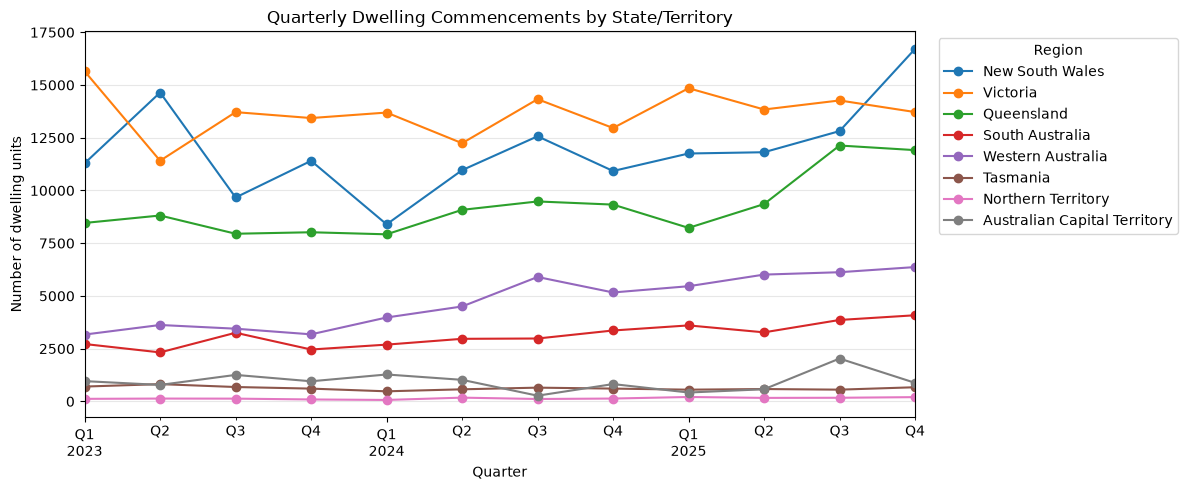

In [21]:
commencements = (
    building[building["MEASURE"] == commenced_code]
    .pivot(
        index="Date",
        columns="REGION",
        values="Dwellings"
    )
    .sort_index()
)

commencements = commencements.rename(
    columns=labels["REGION"]
)

ax = commencements.plot(figsize=(12, 5), marker="o")

ax.set_title("Quarterly Dwelling Commencements by State/Territory")
ax.set_xlabel("Quarter")
ax.set_ylabel("Number of dwelling units")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

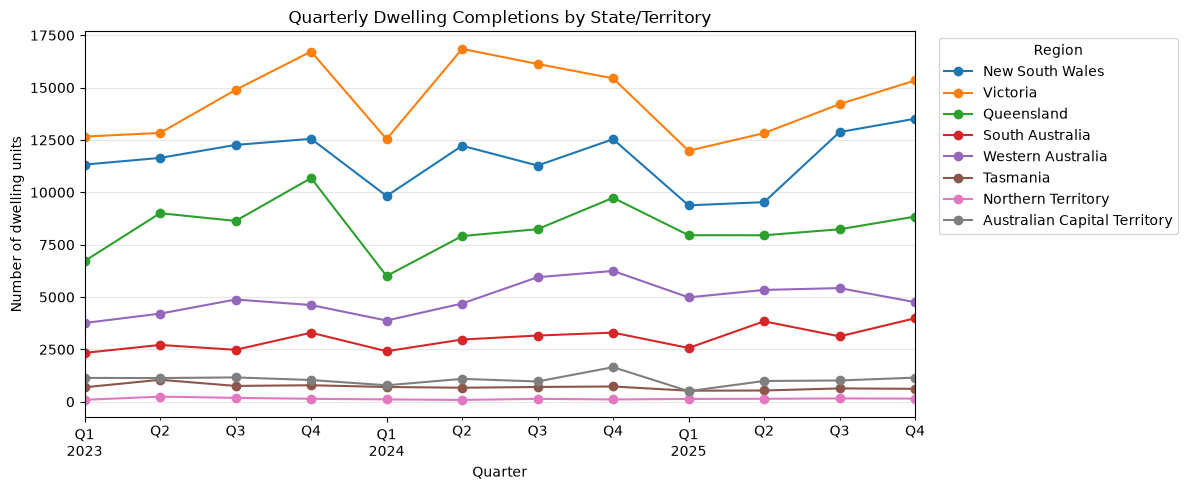

In [22]:
completions = (
    building[building["MEASURE"] == completed_code]
    .pivot(
        index="Date",
        columns="REGION",
        values="Dwellings"
    )
    .sort_index()
)

completions = completions.rename(
    columns=labels["REGION"]
)

ax = completions.plot(figsize=(12, 5), marker="o")

ax.set_title("Quarterly Dwelling Completions by State/Territory")
ax.set_xlabel("Quarter")
ax.set_ylabel("Number of dwelling units")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

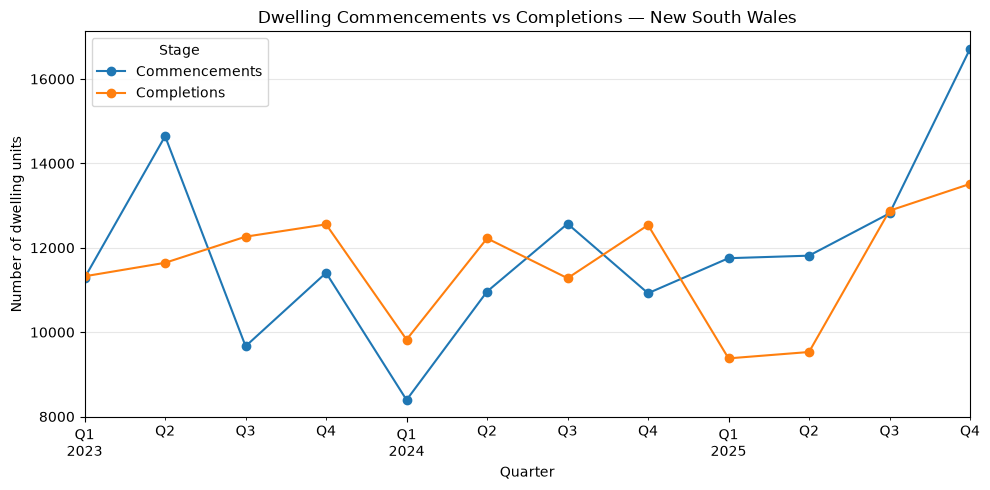

In [23]:
selected_region = "1"

stage_comparison = (
    building[
        (building["REGION"] == selected_region)
        & building["MEASURE"].isin([
            commenced_code,
            completed_code
        ])
    ]
    .pivot(
        index="Date",
        columns="MEASURE",
        values="Dwellings"
    )
    .sort_index()
    .rename(columns={
        commenced_code: "Commencements",
        completed_code: "Completions"
    })
)

region_name = labels["REGION"].get(
    selected_region, selected_region
)

ax = stage_comparison.plot(
    figsize=(10, 5),
    marker="o"
)

ax.set_title(f"Dwelling Commencements vs Completions — {region_name}")
ax.set_xlabel("Quarter")
ax.set_ylabel("Number of dwelling units")
ax.legend(title="Stage")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

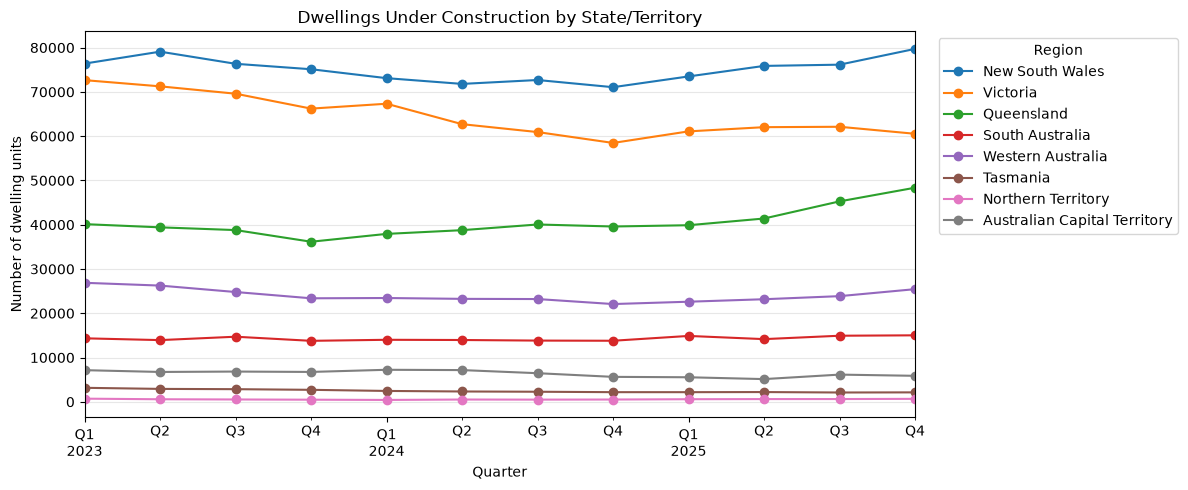

In [24]:
under_construction = (
    building[building["MEASURE"] == construction_code]
    .pivot(
        index="Date",
        columns="REGION",
        values="Dwellings"
    )
    .sort_index()
)

under_construction = under_construction.rename(
    columns=labels["REGION"]
)

ax = under_construction.plot(
    figsize=(12, 5),
    marker="o"
)

ax.set_title("Dwellings Under Construction by State/Territory")
ax.set_xlabel("Quarter")
ax.set_ylabel("Number of dwelling units")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
approvals_chart = approvals[
    (approvals["MEASURE"].astype(str) == "1")
    & (approvals["SECTOR"].astype(str) == "9")
    & (approvals["WORK_TYPE"] == "TOT")
    & (approvals["BUILDING_TYPE"] == "TOT")
    & (approvals["REGION_TYPE"] == "STE")
].copy()

print("Rows selected:", len(approvals_chart))

assert not approvals_chart.empty, "Bộ lọc không trả về dữ liệu."

assert not approvals_chart.duplicated(
    subset=["REGION", "TIME_PERIOD"]
).any(), "Có nhiều dòng cho cùng một bang–tháng."

Rows selected: 264


In [30]:
trend = trend.rename(
    columns=lambda code: region_names.get(str(code), code)
)

# Chạy lại phần trend.plot(...) và đổi:
ax.legend(title="State/Territory", bbox_to_anchor=(1.02, 1))

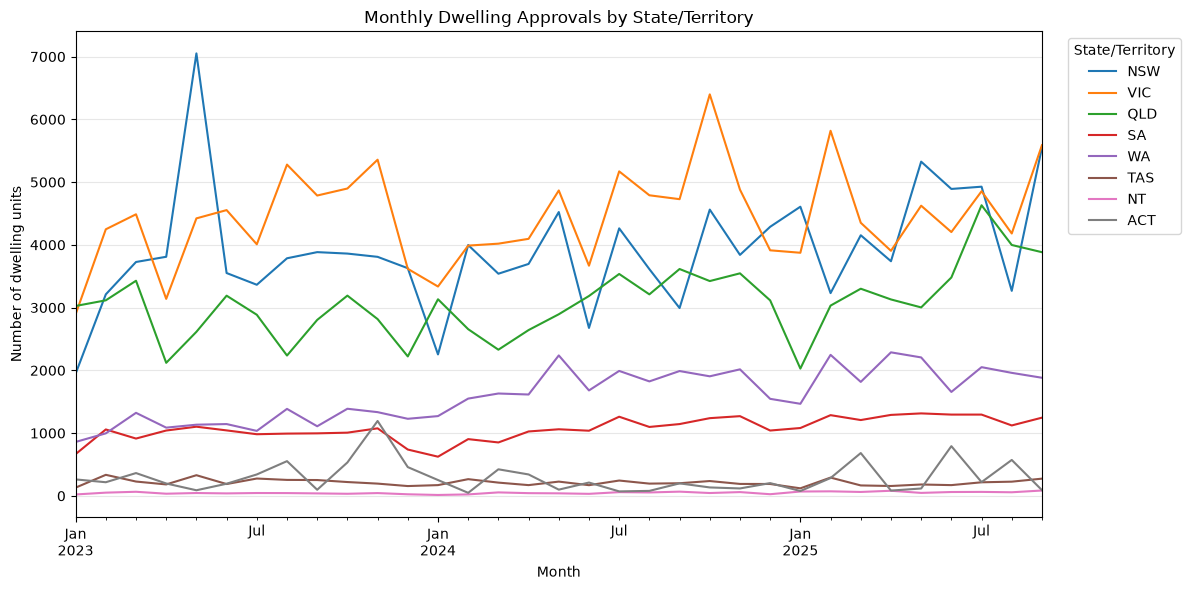

In [32]:
approvals_chart["TIME_PERIOD"] = pd.to_datetime(
    approvals_chart["TIME_PERIOD"]
)

approvals_chart["OBS_VALUE"] = pd.to_numeric(
    approvals_chart["OBS_VALUE"],
    errors="raise"
)
trend = trend.rename(
    columns=lambda code: region_names.get(str(code), code)
)

ax = trend.plot(figsize=(12, 6))

ax.set_title("Monthly Dwelling Approvals by State/Territory")
ax.set_xlabel("Month")
ax.set_ylabel("Number of dwelling units")

ax.legend(title="State/Territory", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

months  values
REGION Year                
1      2023       9       9
       2024       9       9
       2025       9       9
2      2023       9       9
       2024       9       9
       2025       9       9
3      2023       9       9
       2024       9       9
       2025       9       9
4      2023       9       9
       2024       9       9
       2025       9       9
5      2023       9       9
       2024       9       9
       2025       9       9
6      2023       9       9
       2024       9       9
       2025       9       9
7      2023       9       9
       2024       9       9
       2025       9       9
8      2023       9       9
       2024       9       9
       2025       9       9

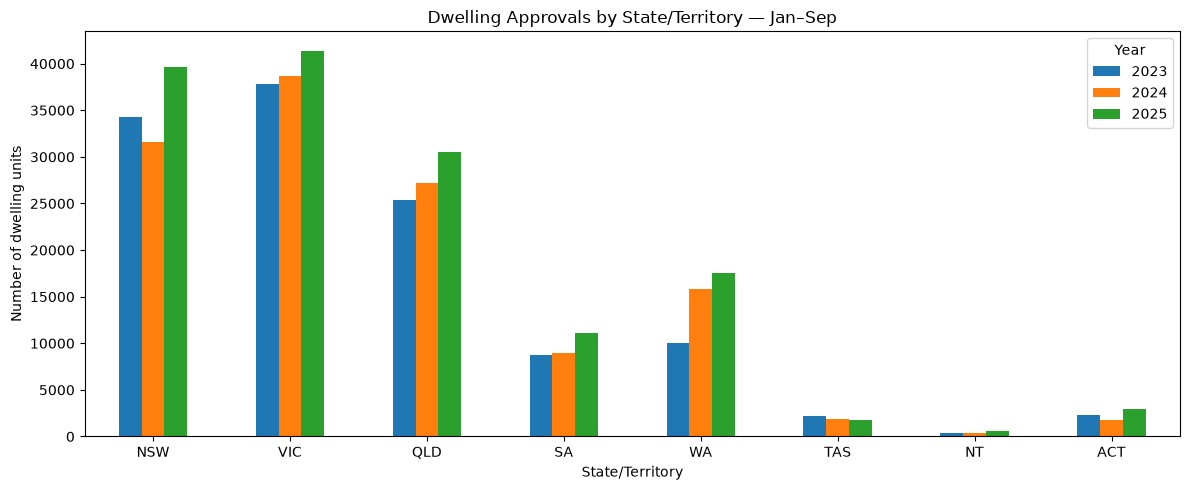

In [39]:
region_names = {
    "1": "NSW", "2": "VIC", "3": "QLD", "4": "SA",
    "5": "WA", "6": "TAS", "7": "NT", "8": "ACT"
}

comparison = approvals_chart.copy()

comparison["TIME_PERIOD"] = pd.to_datetime(
    comparison["TIME_PERIOD"]
)

comparison["OBS_VALUE"] = pd.to_numeric(
    comparison["OBS_VALUE"], errors="raise"
)

comparison["Year"] = comparison["TIME_PERIOD"].dt.year
comparison["Month"] = comparison["TIME_PERIOD"].dt.month

comparison = comparison[
    comparison["Year"].isin([2023, 2024, 2025])
    & (comparison["Month"] <= 9)
]

coverage = comparison.groupby(["REGION", "Year"]).agg(
    months=("Month", "nunique"),
    values=("OBS_VALUE", "count")
)

display(coverage)

assert coverage["months"].eq(9).all(), "Có nhóm thiếu tháng."
assert coverage["values"].eq(9).all(), "Có nhóm thiếu giá trị."

# Tạo bảng tổng trước khi đổi tên region
totals = (
    comparison
    .groupby(["REGION", "Year"])["OBS_VALUE"]
    .sum()
    .unstack("Year")
)

# Đổi mã region thành tên bang
totals = totals.rename(
    index=lambda code: region_names.get(str(code), str(code))
)

ax = totals.plot.bar(figsize=(12, 5))

ax.set_title("Dwelling Approvals by State/Territory — Jan–Sep")
ax.set_xlabel("State/Territory")
ax.set_ylabel("Number of dwelling units")
ax.legend(title="Year")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

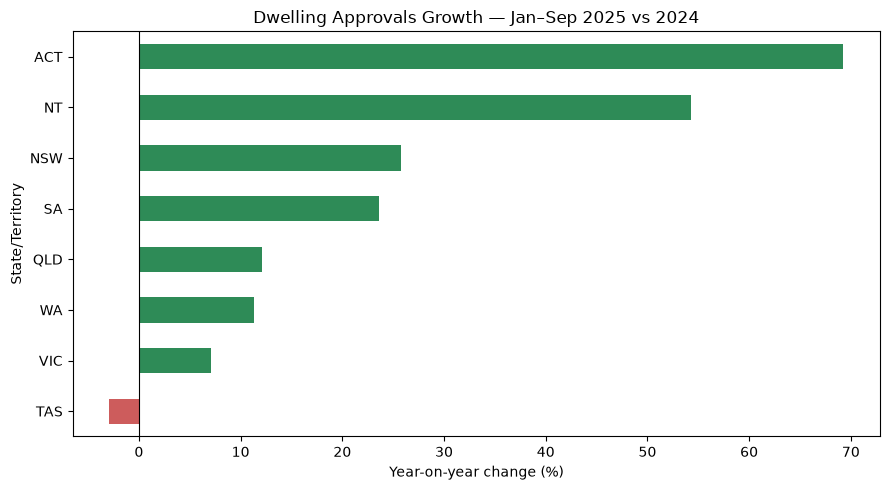

,Growth (%)
REGION,
TAS,-2.91
VIC,7.08
WA,11.29
QLD,12.08
SA,23.65
NSW,25.79
NT,54.26
ACT,69.26


In [35]:
growth = rename_regions(growth)


colors = [
    "seagreen" if value >= 0 else "indianred"
    for value in growth
]

ax = growth.plot.barh(
    figsize=(9, 5),
    color=colors
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Dwelling Approvals Growth — Jan–Sep 2025 vs 2024")
ax.set_xlabel("Year-on-year change (%)")
ax.set_ylabel("State/Territory")

plt.tight_layout()
plt.show()

display(growth.round(2).rename("Growth (%)").to_frame())

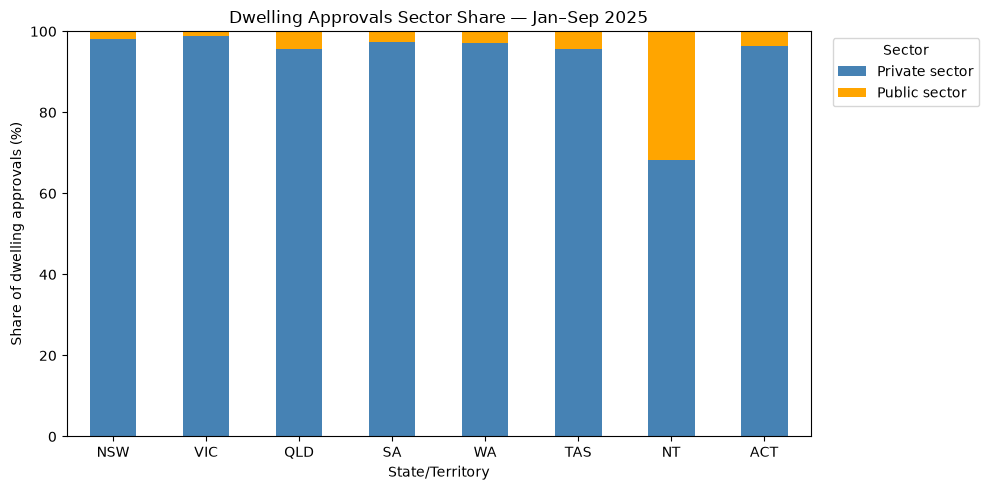

In [36]:
sector_data = approvals[
    (approvals["MEASURE"].astype(str) == "1")
    & (approvals["SECTOR"].astype(str).isin(["1", "5"]))
    & (approvals["WORK_TYPE"] == "TOT")
    & (approvals["BUILDING_TYPE"] == "TOT")
    & (approvals["REGION_TYPE"] == "STE")
].copy()

sector_data["TIME_PERIOD"] = pd.to_datetime(
    sector_data["TIME_PERIOD"]
)

sector_data["OBS_VALUE"] = pd.to_numeric(
    sector_data["OBS_VALUE"],
    errors="raise"
)

sector_data = sector_data[
    (sector_data["TIME_PERIOD"].dt.year == 2025)
    & (sector_data["TIME_PERIOD"].dt.month <= 9)
]

assert not sector_data.duplicated(
    ["REGION", "SECTOR", "TIME_PERIOD"]
).any(), "Có key trùng."

sector_coverage = sector_data.groupby(
    ["REGION", "SECTOR"]
).agg(
    months=("TIME_PERIOD", "nunique"),
    values=("OBS_VALUE", "count")
)

assert sector_coverage["months"].eq(9).all(), "Có nhóm thiếu tháng."
assert sector_coverage["values"].eq(9).all(), "Có nhóm thiếu giá trị."

sector_data["Sector"] = (
    sector_data["SECTOR"].astype(str).map({
        "1": "Private sector",
        "5": "Public sector"
    })
)

sector_totals = (
    sector_data
    .groupby(["REGION", "Sector"])["OBS_VALUE"]
    .sum()
    .unstack("Sector")
)

assert sector_totals.notna().all().all(), "Có bang thiếu sector."

sector_share = rename_regions(sector_share)

ax = sector_share.plot.bar(
    stacked=True,
    figsize=(10, 5),
    color=["steelblue", "orange"]
)

ax.set_title("Dwelling Approvals Sector Share — Jan–Sep 2025")
ax.set_xlabel("State/Territory")
ax.set_ylabel("Share of dwelling approvals (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Sector", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()